Name: James Fisher
Date: March 15, 2026
Course: DDS-8555 (Predictive Analytics)
Assignment: Week 3
    a. Applied Question 8 in ISLR (assigned)
    b. Additional Models on Kaggle Abalone Data

In [3]:
## Applied Question 8 in ISLR

# Load libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import KFold
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import matplotlib.pyplot as plt

# Set random seed for reproducibility
rng = np.random.default_rng(777)

# (a) Generate synthetic data
n = 100
X = rng.normal(loc=0, scale=1, size=n)
eps = rng.normal(loc=0, scale=1, size=n)

# (b) Generate response vecor Y of length n = 100 according to the model
beta0 = 1
beta1 = 2
beta2 = 3
beta3 = 4

Y = beta0 + beta1*X + beta2*(X**2) + beta3*(X**3) + eps

# (c) Use forward stepwise selection to select a model containing the predictors, X, X^2,... X^10.
# Create predictors
df = pd.DataFrame({
    f"X{i}": X**i for i in range(1, 11)
})
df["Y"] = Y

X_poly = df[[f"X{i}" for i in range(1, 11)]]
y = df["Y"]

# Forward stepwise selection
# Full model for sigma^2 estimate
full_model = LinearRegression()
full_model.fit(X_poly, y)
y_full_pred = full_model.predict(X_poly)
rss_full = np.sum((y - y_full_pred)**2)

n = len(y)
p_full = X_poly.shape[1] + 1  # predictors + intercept
sigma2_hat = rss_full / (n - p_full)

forward_results = []

for k in range(1, 11):
    sfs_forward = SFS(
        LinearRegression(),
        k_features=k,
        forward=True,
        floating=False,
        scoring='neg_mean_squared_error',
        cv=0
    )
    sfs_forward.fit(X_poly, y)

    selected_features = list(sfs_forward.k_feature_names_)
    X_selected = X_poly[selected_features]

    model = LinearRegression()
    model.fit(X_selected, y)
    y_pred = model.predict(X_selected)

    rss = np.sum((y - y_pred)**2)
    p = k + 1  # add intercept
    cp = rss / sigma2_hat - (n - 2*p)

    forward_results.append({
        "k": k,
        "features": selected_features,
        "rss": rss,
        "cp": cp,
        "intercept": model.intercept_,
        "coefficients": dict(zip(selected_features, model.coef_))
    })

forward_df = pd.DataFrame(forward_results)
print(forward_df[["k", "features", "cp"]])

# Pick model with smallest Cp
best_forward = forward_df.loc[forward_df["cp"].idxmin()]
print("\nBest forward model by Cp:")
print("k =", best_forward["k"])
print("Features =", best_forward["features"])
print("Intercept =", best_forward["intercept"])
print("Coefficients =", best_forward["coefficients"])
print("Cp =", best_forward["cp"])


    k                                   features           cp
0   1                                       [X3]  2254.544013
1   2                                   [X2, X3]   131.006511
2   3                               [X1, X2, X3]     3.124626
3   4                           [X1, X2, X3, X6]     4.539749
4   5                       [X1, X2, X3, X6, X7]     6.453508
5   6                   [X1, X2, X3, X6, X7, X9]     8.304378
6   7               [X1, X2, X3, X5, X6, X7, X9]     7.061560
7   8           [X1, X2, X3, X5, X6, X7, X8, X9]     8.940696
8   9       [X1, X2, X3, X4, X5, X6, X7, X8, X9]    10.690342
9  10  [X1, X2, X3, X4, X5, X6, X7, X8, X9, X10]    11.000000

Best forward model by Cp:
k = 3
Features = ['X1', 'X2', 'X3']
Intercept = 0.8180176691940224
Coefficients = {'X1': np.float64(1.9592331636416946), 'X2': np.float64(3.135588360113197), 'X3': np.float64(3.9958047913986885)}
Cp = 3.124626340736981


In [4]:
# (d) Repeat the same procedure using backward stepwise selection
backward_results = []

for k in range(1, 11):
    sfs_backward = SFS(
        LinearRegression(),
        k_features=k,
        forward=False,
        floating=False,
        scoring='neg_mean_squared_error',
        cv=0
    )
    sfs_backward.fit(X_poly, y)

    selected_features = list(sfs_backward.k_feature_names_)
    X_selected = X_poly[selected_features]

    model = LinearRegression()
    model.fit(X_selected, y)
    y_pred = model.predict(X_selected)

    rss = np.sum((y - y_pred)**2)
    p = k + 1
    cp = rss / sigma2_hat - (n - 2*p)

    backward_results.append({
        "k": k,
        "features": selected_features,
        "rss": rss,
        "cp": cp,
        "intercept": model.intercept_,
        "coefficients": dict(zip(selected_features, model.coef_))
    })

backward_df = pd.DataFrame(backward_results)
print(backward_df[["k", "features", "cp"]])

# Pick best model (smallest Cp)
best_backward = backward_df.loc[backward_df["cp"].idxmin()]
print("\nBest backward model by Cp:")
print("k =", best_backward["k"])
print("Features =", best_backward["features"])
print("Intercept =", best_backward["intercept"])
print("Coefficients =", best_backward["coefficients"])
print("Cp =", best_backward["cp"])

    k                                   features           cp
0   1                                       [X3]  2254.544013
1   2                                   [X2, X3]   131.006511
2   3                               [X1, X2, X3]     3.124626
3   4                           [X1, X2, X3, X7]     4.872680
4   5                       [X1, X2, X3, X7, X9]     6.562109
5   6                   [X1, X2, X3, X5, X7, X9]     5.176609
6   7               [X1, X2, X3, X5, X6, X7, X9]     7.061560
7   8           [X1, X2, X3, X5, X6, X7, X8, X9]     8.940696
8   9       [X1, X2, X3, X4, X5, X6, X7, X8, X9]    10.690342
9  10  [X1, X2, X3, X4, X5, X6, X7, X8, X9, X10]    11.000000

Best backward model by Cp:
k = 3
Features = ['X1', 'X2', 'X3']
Intercept = 0.8180176691940224
Coefficients = {'X1': np.float64(1.9592331636416946), 'X2': np.float64(3.135588360113197), 'X3': np.float64(3.9958047913986885)}
Cp = 3.124626340736981


In [7]:
# (e) Fit a lasso model using cross-validation

cv = KFold(n_splits=10, shuffle=True, random_state=1)

lasso_cv = LassoCV(cv=cv, random_state=1, max_iter=100000)
lasso_cv.fit(X_poly, y)

print("Optimal lambda (alpha):", lasso_cv.alpha_)

# Coefficients of the lasso model
lasso_coefs = pd.Series(lasso_cv.coef_, index=X_poly.columns)
print("\nLasso coefficients:")
print(lasso_coefs)
print("\nIntercept:", lasso_cv.intercept_)

Optimal lambda (alpha): 8.746129291790053

Lasso coefficients:
X1     0.000000
X2     0.000000
X3     0.000000
X4     0.000000
X5     0.000000
X6     0.000000
X7     0.504094
X8     0.055377
X9    -0.063358
X10   -0.006704
dtype: float64

Intercept: 1.496769385645837


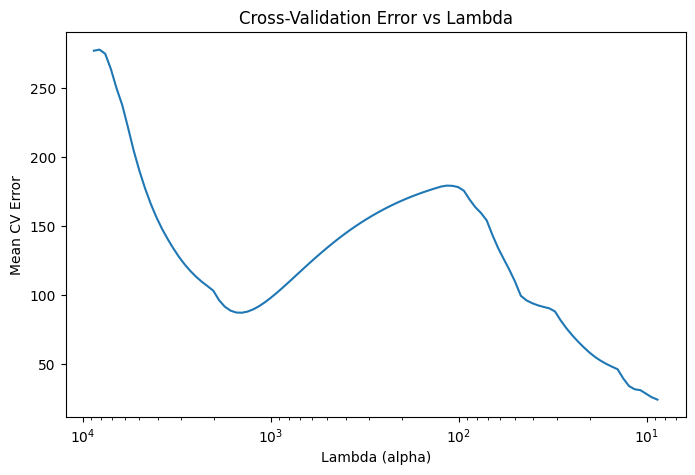

In [8]:
# (e) Also create plots of cross-validation error
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)
plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Lambda (alpha)")
plt.ylabel("Mean CV Error")
plt.title("Cross-Validation Error vs Lambda")
plt.gca().invert_xaxis()
plt.show()

In [10]:
# f. Generate a response vector Y according to the model Y = B0 + b7X7 + eps

# Create predictors
beta0 = 1
beta7 = 5

# Regenerate response only with X7
Y2 = beta0 + beta7*(X**7) + eps
df["Y2"] = Y2
y2 = df["Y2"]

# Recalculate sigma^2 estimate using the new response
full_model2 = LinearRegression()
full_model2.fit(X_poly, y2)
y2_full_pred = full_model2.predict(X_poly)
rss_full2 = np.sum((y2 - y2_full_pred)**2)

sigma2_hat2 = rss_full2 / (n - p_full)

# Perform forward selection again with new response
forward_results_y2 = []

for k in range(1, 11):
    sfs_forward2 = SFS(
        LinearRegression(),
        k_features=k,
        forward=True,
        floating=False,
        scoring='neg_mean_squared_error',
        cv=0
    )
    sfs_forward2.fit(X_poly, y2)

    selected_features = list(sfs_forward2.k_feature_names_)
    X_selected = X_poly[selected_features]

    model = LinearRegression()
    model.fit(X_selected, y2)
    y_pred = model.predict(X_selected)

    rss = np.sum((y2 - y_pred)**2)
    p = k + 1
    cp = rss / sigma2_hat2 - (n - 2*p)

    forward_results_y2.append({
        "k": k,
        "features": selected_features,
        "rss": rss,
        "cp": cp,
        "intercept": model.intercept_,
        "coefficients": dict(zip(selected_features, model.coef_))
    })

forward_y2_df = pd.DataFrame(forward_results_y2)
best_forward_y2 = forward_y2_df.loc[forward_y2_df["cp"].idxmin()]

print("\nBest forward model for Y2 by Cp:")
print("k =", best_forward_y2["k"])
print("Features =", best_forward_y2["features"])
print("Intercept =", best_forward_y2["intercept"])
print("Coefficients =", best_forward_y2["coefficients"])
print("Cp =", best_forward_y2["cp"])

# Perform Lasso on the new response
lasso_cv_y2 = LassoCV(cv=cv, random_state=1, max_iter=100000)
lasso_cv_y2.fit(X_poly, y2)

lasso_y2_coefs = pd.Series(lasso_cv_y2.coef_, index=X_poly.columns)

print("\nOptimal lambda (alpha) for Y2:", lasso_cv_y2.alpha_)
print("\nLasso coefficients for Y2:")
print(lasso_y2_coefs)
print("\nNonzero lasso coefficients for Y2:")
print(lasso_y2_coefs[lasso_y2_coefs != 0])




Best forward model for Y2 by Cp:
k = 2
Features = ['X4', 'X7']
Intercept = 0.8909111236897687
Coefficients = {'X4': np.float64(0.027179698799222128), 'X7': np.float64(4.999515780957239)}
Cp = 0.9398236192555061

Optimal lambda (alpha) for Y2: 346.8568079997723

Lasso coefficients for Y2:
X1     0.000000
X2    -0.000000
X3     0.000000
X4    -0.000000
X5     0.000000
X6    -0.000000
X7     3.325403
X8    -0.000000
X9     0.283459
X10    0.000217
dtype: float64

Nonzero lasso coefficients for Y2:
X7     3.325403
X9     0.283459
X10    0.000217
dtype: float64


Now, on to the Abalone Dataset. The purposes here are to create two additional models for the Kaggle Abalone dataset challenge, one using regularization and the second principle component regression. Interpretation and investigation of assumptions and outputs of each regression model is provided in the included document. 

In [58]:
###################################
## KAGGLE COMPETITION CODE BELOW ##
####################################

In [18]:
import warnings
warnings.filterwarnings("ignore")

# Load libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import OLSInfluence

# Load/prepare data
train = pd.read_csv("lotr/train.csv")
test = pd.read_csv("lotr/test.csv")
sample_submission = pd.read_csv("lotr/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns:")
print(train.columns.tolist())
print("\nSample submission head:")
print(sample_submission.head())

y = train["Rings"]

X_raw = train.drop(columns=["id", "Rings"])
X_test_raw = test.drop(columns=["id"])

# One-hot encode Sex
X_raw = pd.get_dummies(X_raw, columns=["Sex"], drop_first=True)
X_test_raw = pd.get_dummies(X_test_raw, columns=["Sex"], drop_first=True)

# Align columns
X_raw, X_test_raw = X_raw.align(X_test_raw, join="left", axis=1, fill_value=0)

# Ensure numeric
X_raw = X_raw.astype(float)
X_test_raw = X_test_raw.astype(float)

print("\nEncoded predictor columns:")
print(X_raw.columns.tolist())

# Create helpers
def regression_metrics(y_true, y_pred, label="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Rounded metrics too, since Rings is integer-valued
    y_pred_round = np.clip(np.round(y_pred), a_min=0, a_max=None)
    rmse_round = np.sqrt(mean_squared_error(y_true, y_pred_round))
    mae_round = mean_absolute_error(y_true, y_pred_round)
    r2_round = r2_score(y_true, y_pred_round)
    exact_acc = np.mean(y_true == y_pred_round)
    
    print(f"\n{label} metrics")
    print("-" * 40)
    print(f"RMSE (raw):        {rmse:.6f}")
    print(f"MAE (raw):         {mae:.6f}")
    print(f"R^2 (raw):         {r2:.6f}")
    print(f"RMSE (rounded):    {rmse_round:.6f}")
    print(f"MAE (rounded):     {mae_round:.6f}")
    print(f"R^2 (rounded):     {r2_round:.6f}")
    print(f"Exact accuracy:    {exact_acc:.6f}")
    
    return {
        "rmse_raw": rmse,
        "mae_raw": mae,
        "r2_raw": r2,
        "rmse_rounded": rmse_round,
        "mae_rounded": mae_round,
        "r2_rounded": r2_round,
        "exact_accuracy": exact_acc
    }


def crossval_rmse(model, X, y, cv):
    scores = cross_val_score(
        model, X, y,
        scoring="neg_root_mean_squared_error",
        cv=cv
    )
    return -scores.mean(), scores


def run_ols_diagnostics(model, X, y, model_name="OLS Model"):
    fitted = model.fittedvalues
    resid = model.resid
    influence = OLSInfluence(model)
    leverage = influence.hat_matrix_diag
    cooks_d = influence.cooks_distance[0]

    print(f"\nDiagnostics for {model_name}")
    print("-" * 50)

    # Normality
    jb_stat, jb_p, skew, kurtosis = jarque_bera(resid)
    print(f"Jarque-Bera p-value:       {jb_p:.6f}")

    # Homoscedasticity
    bp_test = het_breuschpagan(resid, X)
    bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
    print("Breusch-Pagan test:")
    for name, value in zip(bp_labels, bp_test):
        print(f"  {name}: {value:.6f}")

    # Influence
    n = len(y)
    p = X.shape[1]
    leverage_cutoff = 2 * p / n
    cooks_cutoff = 4 / n

    print(f"High leverage cutoff (2p/n): {leverage_cutoff:.6f}")
    print(f"Cook's distance cutoff (4/n): {cooks_cutoff:.6f}")
    print(f"Number of high leverage points: {(leverage > leverage_cutoff).sum()}")
    print(f"Number of influential points:   {(cooks_d > cooks_cutoff).sum()}")

    # Plots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Residuals vs fitted
    axes[0, 0].scatter(fitted, resid, alpha=0.5)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals vs Fitted")
    axes[0, 0].set_xlabel("Fitted values")
    axes[0, 0].set_ylabel("Residuals")

    # Histogram
    axes[0, 1].hist(resid, bins=30)
    axes[0, 1].set_title("Residual Histogram")
    axes[0, 1].set_xlabel("Residual")
    axes[0, 1].set_ylabel("Frequency")

    # QQ plot
    sm.qqplot(resid, line="45", ax=axes[1, 0])
    axes[1, 0].set_title("QQ Plot")

    # Cook's distance
    axes[1, 1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
    axes[1, 1].axhline(cooks_cutoff, linestyle="--")
    axes[1, 1].set_title("Cook's Distance")
    axes[1, 1].set_xlabel("Observation")
    axes[1, 1].set_ylabel("Cook's D")

    plt.tight_layout()
    plt.show()


def make_submission(pred, filename):
    submission = sample_submission.copy()
    submission["Rings"] = np.round(pred).astype(int)
    submission["Rings"] = submission["Rings"].clip(lower=0)
    submission.to_csv(filename, index=False)
    print(f"{filename} created")
    print(submission.head())
    return submission


# Cross-validation object
cv = KFold(n_splits=10, shuffle=True, random_state=42)

Train shape: (90615, 10)
Test shape: (60411, 9)

Train columns:
['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings']

Sample submission head:
      id  Rings
0  90615     10
1  90616     10
2  90617     10
3  90618     10
4  90619     10

Encoded predictor columns:
['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Sex_I', 'Sex_M']



Engineered feature matrix shape: (90615, 22)

ElasticNet selected features:
['Length', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Sex_I', 'Sex_M', 'Length_sq', 'Height_sq', 'Whole weight_sq', 'Whole weight.1_sq', 'Shell weight_sq', 'Length_x_Diameter', 'Whole weight_x_Shell weight', 'Whole weight.1_x_Whole weight.2']

ElasticNet alpha: 0.001
ElasticNet l1_ratio: 1.0

ElasticNet coefficients:
Whole weight.1                    -5.634415
Whole weight                       4.713324
Shell weight                       4.416497
Whole weight_x_Shell weight       -2.436797
Whole weight.1_sq                  2.347861
Length_sq                         -2.299654
Length                             1.536082
Height                             0.783034
Whole weight.1_x_Whole weight.2   -0.565534
Whole weight_sq                   -0.456475
Length_x_Diameter                 -0.233460
Sex_I                             -0.224404
Height_sq                         -0.204

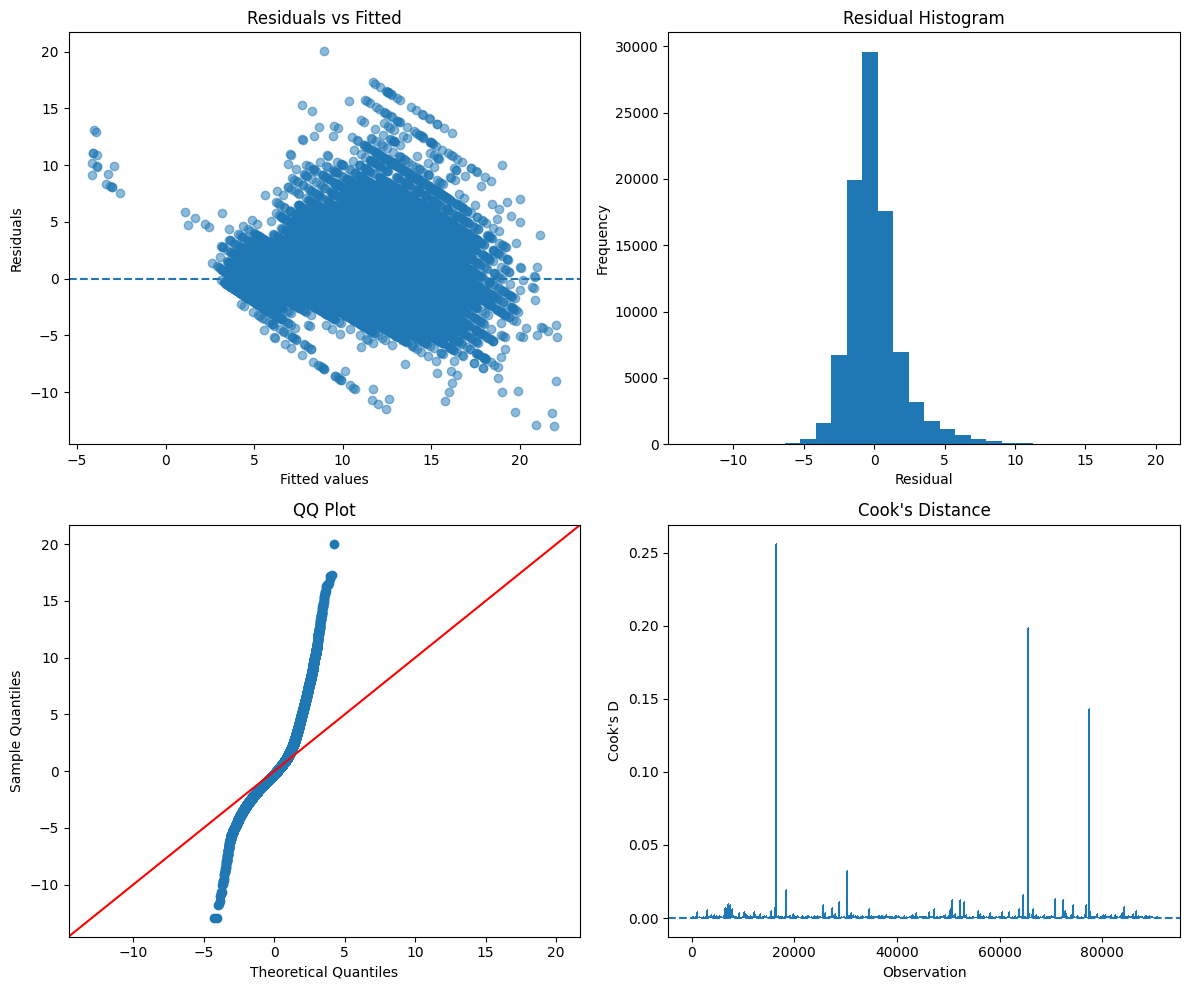

submission_regularized_subset.csv created
      id  Rings
0  90615      9
1  90616     10
2  90617     11
3  90618     10
4  90619      8


In [19]:
## MODEL 1: Regularization-informed best subset selection
# Add some nonlinearity and interactions to give regularization something useful to screen
X_eng = X_raw.copy()
X_test_eng = X_test_raw.copy()

base_cols = X_raw.columns.tolist()

# Polynomial terms for continuous predictors
continuous_cols = [c for c in base_cols if c not in ["Sex_I", "Sex_M"]]

for col in continuous_cols:
    X_eng[f"{col}_sq"] = X_raw[col] ** 2
    X_test_eng[f"{col}_sq"] = X_test_raw[col] ** 2

# Selected interaction terms based on domain logic
interaction_pairs = [
    ("Length", "Diameter"),
    ("Length", "Height"),
    ("Length", "Whole weight"),
    ("Diameter", "Height"),
    ("Whole weight", "Shell weight"),
    ("Whole weight.1", "Whole weight.2")
]

for a, b in interaction_pairs:
    if a in X_raw.columns and b in X_raw.columns:
        X_eng[f"{a}_x_{b}"] = X_raw[a] * X_raw[b]
        X_test_eng[f"{a}_x_{b}"] = X_test_raw[a] * X_test_raw[b]

print("\nEngineered feature matrix shape:", X_eng.shape)

# Standardize for ElasticNet
scaler_en = StandardScaler()
X_eng_scaled = scaler_en.fit_transform(X_eng)
X_test_eng_scaled = scaler_en.transform(X_test_eng)

# ElasticNetCV
enet = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    alphas=np.logspace(-3, 1, 100),
    cv=cv,
    max_iter=200000,
    random_state=42
)

enet.fit(X_eng_scaled, y)

enet_coefs = pd.Series(enet.coef_, index=X_eng.columns)
selected_features = enet_coefs[enet_coefs != 0].index.tolist()

print("\nElasticNet selected features:")
print(selected_features)
print("\nElasticNet alpha:", enet.alpha_)
print("ElasticNet l1_ratio:", enet.l1_ratio_)
print("\nElasticNet coefficients:")
print(enet_coefs[enet_coefs != 0].sort_values(key=np.abs, ascending=False))

# If too many or too few are selected, optionally refine
# Keep top features by absolute coefficient if large set
if len(selected_features) > 12:
    top_features = enet_coefs.abs().sort_values(ascending=False).head(12).index.tolist()
    selected_features = top_features
    print("\nTrimmed to top 12 features by absolute coefficient:")
    print(selected_features)

if len(selected_features) == 0:
    raise ValueError("ElasticNet selected no predictors. Try expanding alpha grid.")

# Refit interpretable OLS on selected subset
X_subset = sm.add_constant(X_eng[selected_features])
X_test_subset = sm.add_constant(X_test_eng[selected_features], has_constant="add")

subset_model = sm.OLS(y, X_subset).fit()

print("\nSUBSET MODEL SUMMARY")
print(subset_model.summary())

# Training predictions
subset_train_pred = subset_model.predict(X_subset)
subset_metrics = regression_metrics(y, subset_train_pred, label="Regularization-informed subset model")

# Cross-validated OLS RMSE on selected subset
linreg_subset = LinearRegression()
subset_cv_rmse, subset_cv_scores = crossval_rmse(linreg_subset, X_eng[selected_features], y, cv)
print(f"\nSubset model 10-fold CV RMSE: {subset_cv_rmse:.6f}")

# Diagnostics
run_ols_diagnostics(subset_model, X_subset, y, model_name="Regularization-informed subset OLS")

# Kaggle submission
subset_test_pred = subset_model.predict(X_test_subset)
submission_subset = make_submission(subset_test_pred, "submission_regularized_subset.csv")



PCR cross-validation results:
   n_components   cv_rmse
0             1  2.418343
1             2  2.418325
2             3  2.398613
3             4  2.327210
4             5  2.189885
5             6  2.006673
6             7  2.005952
7             8  1.995322
8             9  1.994970

Best number of principal components: 9


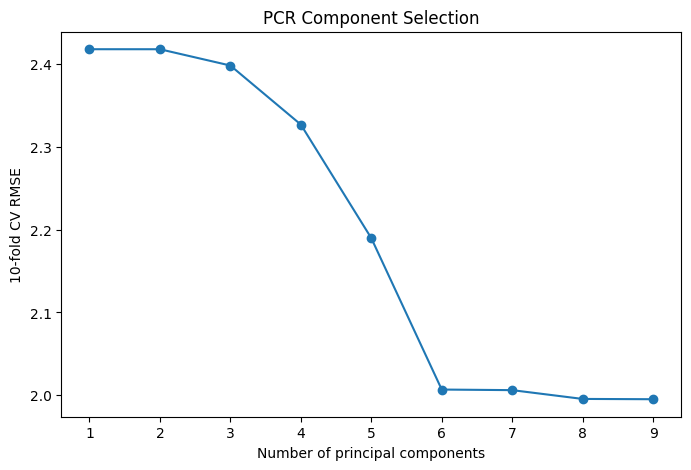


PCR model metrics
----------------------------------------
RMSE (raw):        1.994730
MAE (raw):         1.373854
R^2 (raw):         0.605587
RMSE (rounded):    2.015150
MAE (rounded):     1.349070
R^2 (rounded):     0.597470
Exact accuracy:    0.276080

Explained variance ratio by retained component:
PC1: 0.797536
PC2: 0.115104
PC3: 0.037979
PC4: 0.021060
PC5: 0.012935
PC6: 0.008101
PC7: 0.004970
PC8: 0.001207
PC9: 0.001109

Cumulative explained variance:
PC1 to PC1: 0.797536
PC1 to PC2: 0.912641
PC1 to PC3: 0.950620
PC1 to PC4: 0.971679
PC1 to PC5: 0.984614
PC1 to PC6: 0.992715
PC1 to PC7: 0.997684
PC1 to PC8: 0.998891
PC1 to PC9: 1.000000

PCR loading matrix:
                     PC1       PC2       PC3       PC4       PC5       PC6  \
Length          0.360380 -0.087787  0.038955  0.392308 -0.455019  0.121100   
Diameter        0.361430 -0.082510  0.024555  0.388411 -0.404315  0.175585   
Height          0.350473 -0.085551 -0.005906  0.517186  0.610399 -0.476383   
Whole weight   

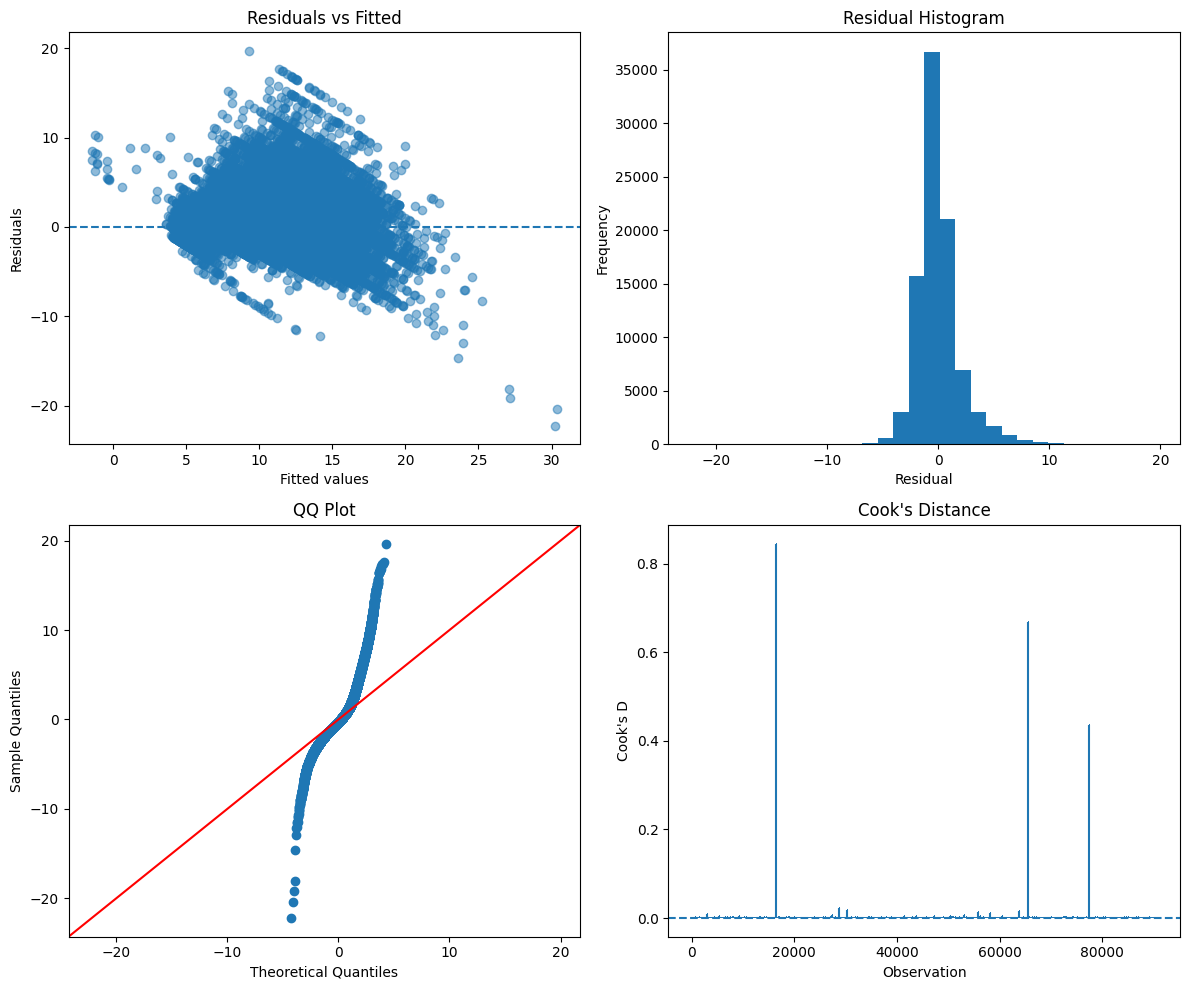

submission_pcr.csv created
      id  Rings
0  90615      9
1  90616     10
2  90617     10
3  90618     11
4  90619      8

MODEL COMPARISON
                            Model  Train RMSE  Train MAE  Train R^2  \
0  Regularization-informed subset    1.931946   1.337976   0.630024   
1                             PCR    1.994730   1.373854   0.605587   

   Rounded Accuracy   CV RMSE  
0          0.281179  1.932316  
1          0.276080  1.994970  

Support files saved:
- elasticnet_coefficients.csv
- pcr_loadings.csv
- pcr_cv_results.csv
- model_comparison.csv


In [21]:
## MODEL 2: Principal Components Regression
# Use original encoded predictors for PCR
X_pcr = X_raw.copy()
X_test_pcr = X_test_raw.copy()

# Search over number of components
component_results = []

for n_comp in range(1, X_pcr.shape[1] + 1):
    pcr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp)),
        ("reg", LinearRegression())
    ])
    
    cv_rmse, scores = crossval_rmse(pcr_pipeline, X_pcr, y, cv)
    component_results.append((n_comp, cv_rmse))

component_results_df = pd.DataFrame(component_results, columns=["n_components", "cv_rmse"])
best_n = component_results_df.loc[component_results_df["cv_rmse"].idxmin(), "n_components"]

print("\nPCR cross-validation results:")
print(component_results_df)
print(f"\nBest number of principal components: {best_n}")

# Plot CV RMSE vs components
plt.figure(figsize=(8, 5))
plt.plot(component_results_df["n_components"], component_results_df["cv_rmse"], marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("10-fold CV RMSE")
plt.title("PCR Component Selection")
plt.show()

# Fit final PCR pipeline
pcr_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=int(best_n))),
    ("reg", LinearRegression())
])

pcr_final.fit(X_pcr, y)

# Train predictions
pcr_train_pred = pcr_final.predict(X_pcr)
pcr_metrics = regression_metrics(y, pcr_train_pred, label="PCR model")

# Explained variance
pca_obj = pcr_final.named_steps["pca"]
explained_var = pca_obj.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

print("\nExplained variance ratio by retained component:")
for i, val in enumerate(explained_var, start=1):
    print(f"PC{i}: {val:.6f}")

print("\nCumulative explained variance:")
for i, val in enumerate(cum_explained_var, start=1):
    print(f"PC1 to PC{i}: {val:.6f}")

# PCA loadings
loadings = pd.DataFrame(
    pca_obj.components_.T,
    index=X_pcr.columns,
    columns=[f"PC{i}" for i in range(1, int(best_n) + 1)]
)

print("\nPCR loading matrix:")
print(loadings)

# Optional full OLS on PCs for diagnostics and inference-like summary
scaler_pcr = StandardScaler()
X_pcr_scaled = scaler_pcr.fit_transform(X_pcr)
X_test_pcr_scaled = scaler_pcr.transform(X_test_pcr)

pca_for_ols = PCA(n_components=int(best_n))
Z_train = pca_for_ols.fit_transform(X_pcr_scaled)
Z_test = pca_for_ols.transform(X_test_pcr_scaled)

Z_train_df = pd.DataFrame(Z_train, columns=[f"PC{i}" for i in range(1, int(best_n) + 1)])
Z_test_df = pd.DataFrame(Z_test, columns=[f"PC{i}" for i in range(1, int(best_n) + 1)])

Z_train_const = sm.add_constant(Z_train_df)
pcr_ols = sm.OLS(y, Z_train_const).fit()

print("\nPCR OLS SUMMARY (response regressed on retained PCs)")
print(pcr_ols.summary())

# Diagnostics for PCR OLS
run_ols_diagnostics(pcr_ols, Z_train_const, y, model_name="PCR OLS on retained PCs")

# Kaggle submission
Z_test_const = sm.add_constant(Z_test_df, has_constant="add")
pcr_test_pred = pcr_ols.predict(Z_test_const)
submission_pcr = make_submission(pcr_test_pred, "submission_pcr.csv")

# =======================================================
# 4. Compare models side-by-side
# =======================================================
comparison = pd.DataFrame([
    {
        "Model": "Regularization-informed subset",
        "Train RMSE": subset_metrics["rmse_raw"],
        "Train MAE": subset_metrics["mae_raw"],
        "Train R^2": subset_metrics["r2_raw"],
        "Rounded Accuracy": subset_metrics["exact_accuracy"],
        "CV RMSE": subset_cv_rmse
    },
    {
        "Model": "PCR",
        "Train RMSE": pcr_metrics["rmse_raw"],
        "Train MAE": pcr_metrics["mae_raw"],
        "Train R^2": pcr_metrics["r2_raw"],
        "Rounded Accuracy": pcr_metrics["exact_accuracy"],
        "CV RMSE": component_results_df["cv_rmse"].min()
    }
])

print("\nMODEL COMPARISON")
print(comparison)

# =======================================================
# 5. Optional: save supporting tables for your report
# =======================================================
enet_coefs.to_csv("elasticnet_coefficients.csv", header=["coefficient"])
loadings.to_csv("pcr_loadings.csv")
component_results_df.to_csv("pcr_cv_results.csv", index=False)
comparison.to_csv("model_comparison.csv", index=False)

print("\nSupport files saved:")
print("- elasticnet_coefficients.csv")
print("- pcr_loadings.csv")
print("- pcr_cv_results.csv")
print("- model_comparison.csv")
